In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load training data and test data

df = pd.read_csv('data/train_data.csv')
df_TEST = pd.read_csv('data/test_data.csv')

In [4]:
column_names = df.columns.tolist()

In [5]:
# split for training/validation + test data by engine_id

# number of unique engines
num_engines = df['engine_id'].nunique()
engines = df['engine_id'].unique()
num_engines_train = int(num_engines * 0.8)
engines_train = engines[-num_engines_train:]

df_TRAIN = df[df['engine_id'].isin(engines_train)]
df_VAL = df[~df['engine_id'].isin(engines_train)]

In [6]:
# create windows of data for LSTM input

def create_windows(df, window_size=5, step_size=1):
    X, y = [], []
    engine_ids = df['engine_id'].unique()
    
    for engine_id in engine_ids:
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')
        features = engine_data.drop(columns=['engine_id', 'RUL']).values
        rul_values = engine_data['RUL'].values
        
        for start in range(0, len(engine_data) - window_size + 1, step_size):
            end = start + window_size
            X.append(features[start:end])
            y.append(rul_values[start:end])  # (sequence-to-sequence)
    
    return np.array(X), np.array(y)

In [7]:
# normalization

numeric_cols = df_TRAIN.select_dtypes(include="number").columns

train_mean = df_TRAIN[numeric_cols].mean()
train_std = df_TRAIN[numeric_cols].std()

df_TRAIN[numeric_cols] = (df_TRAIN[numeric_cols] - train_mean) / train_std
df_VAL[numeric_cols] = (df_VAL[numeric_cols] - train_mean) / train_std
df_TEST[numeric_cols] = (df_TEST[numeric_cols] - train_mean) / train_std

/var/folders/6q/cww8_z5x7j16f4g86cdmpm0m0000gn/T/ipykernel_24260/2194000443.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_TRAIN[numeric_cols] = (df_TRAIN[numeric_cols] - train_mean) / train_std
/var/folders/6q/cww8_z5x7j16f4g86cdmpm0m0000gn/T/ipykernel_24260/2194000443.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VAL[numeric_cols] = (df_VAL[numeric_cols] - train_mean) / train_std


In [8]:
WINDOWS_SIZE = 10

X_train, y_train = create_windows(df_TRAIN, window_size=WINDOWS_SIZE)
X_val, y_val = create_windows(df_VAL, window_size=WINDOWS_SIZE)
X_test, y_test = create_windows(df_TEST, window_size=WINDOWS_SIZE)

# normalization values:

In [9]:
df_TRAIN

,engine_id,cycle,altitude,mach_number,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,bypass_press,HPC_outlet_press,fan_speed,core_speed,HPC_static_outlet_press,fuel_flow_ratio,corrected_fan_speed,corrected_core_speed,bypass_ratio,bleed_enthalpy,HPT_coolant_bleed,LPT_coolant_bleed,RUL
3264,24_FD001,-1.546572,0.373227,-1.380991,-1.014162,-0.414671,-0.639739,0.139721,0.714009,-0.365915,0.064902,-1.652044,0.902469,-1.362778,0.126654,-1.037124,-1.419264,1.456729,0.634431,0.993920
3265,24_FD001,-1.532626,0.784356,0.325239,-1.356674,-1.135938,-1.606739,0.139721,0.817235,-1.967972,-0.257201,-1.387120,1.149872,-0.931651,0.057808,-1.069247,-0.770893,0.620996,1.997080,0.973947
3266,24_FD001,-1.518680,0.007778,-0.698499,-0.490320,-0.472045,-1.059930,0.139721,1.276014,-0.657198,0.153057,-0.630195,1.232339,-1.219069,-0.141393,0.180859,-2.067634,0.008126,0.328416,0.953974
3267,24_FD001,-1.504734,0.510270,0.666484,0.235001,-0.450735,-0.634136,0.139721,0.702540,-0.657198,-0.101719,-1.046504,1.617187,-1.793905,0.150354,-0.954141,-0.122523,1.011005,1.354356,0.934002
3268,24_FD001,-1.490788,0.053459,1.007730,-0.369433,-1.849008,-1.109233,0.139721,0.404333,-1.094122,-0.297403,-0.705888,0.393920,-1.506487,0.133425,0.646637,-0.122523,0.008126,0.677217,0.914029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,99_FD001,0.963706,-0.677438,-0.357253,2.108745,1.632742,2.151454,0.139721,-2.623611,2.546917,-0.504712,2.624583,-2.506185,2.804786,-1.145297,1.251613,1.822588,-1.774770,-2.313170,-1.842213
16733,99_FD001,0.977652,-1.225611,-1.039745,1.705789,2.442528,2.408051,0.139721,-2.027198,2.401275,-0.096391,2.359659,-2.891033,2.517368,-0.725452,1.891388,-0.122523,-2.387641,-3.011702,-1.862186
16734,99_FD001,0.991598,-1.408336,-1.039745,2.592292,2.708085,2.136887,0.139721,-2.887409,3.275125,-0.460150,3.570739,-2.382483,3.092204,-0.956254,2.560610,1.174218,-1.384762,-1.369082,-1.882159
16735,99_FD001,1.005544,-0.449033,-0.357253,2.874361,1.601596,3.105009,0.139721,-2.141893,2.838200,-0.218451,2.208274,-2.176315,3.379622,-1.026228,3.144171,1.174218,-2.053348,-2.263873,-1.902132


In [10]:
df_TRAIN.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['engine_id', 'cycle', 'altitude', 'mach_number', 'LPC_outlet_temp',
       'HPC_outlet_temp', 'LPT_outlet_temp', 'bypass_press',
       'HPC_outlet_press', 'fan_speed', 'core_speed',
       'HPC_static_outlet_press', 'fuel_flow_ratio', 'corrected_fan_speed',
       'corrected_core_speed', 'bypass_ratio', 'bleed_enthalpy',
       'HPT_coolant_bleed', 'LPT_coolant_bleed', 'RUL'],
      dtype='object')>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

W = X_train.shape[1] # window size
F = X_train.shape[2] # features

model = models.Sequential([
    layers.Input(shape=(W, F)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=True),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['mae']
)

model.summary()


2026-02-24 12:02:15.477084: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train[..., np.newaxis],
    validation_data=(X_val, y_val[..., np.newaxis]),
    epochs=100,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True
        )
    ],
    verbose=2
)


Epoch 1/100
202/202 - 5s - 23ms/step - loss: 0.4206 - mae: 0.4206 - val_loss: 0.2957 - val_mae: 0.2957
Epoch 2/100
202/202 - 2s - 7ms/step - loss: 0.3310 - mae: 0.3310 - val_loss: 0.2642 - val_mae: 0.2642
Epoch 3/100
202/202 - 2s - 8ms/step - loss: 0.3083 - mae: 0.3083 - val_loss: 0.2470 - val_mae: 0.2470
Epoch 4/100
202/202 - 2s - 8ms/step - loss: 0.2949 - mae: 0.2949 - val_loss: 0.2412 - val_mae: 0.2412
Epoch 5/100
202/202 - 2s - 8ms/step - loss: 0.2867 - mae: 0.2867 - val_loss: 0.2400 - val_mae: 0.2400
Epoch 6/100
202/202 - 2s - 10ms/step - loss: 0.2799 - mae: 0.2799 - val_loss: 0.2449 - val_mae: 0.2449
Epoch 7/100
202/202 - 2s - 10ms/step - loss: 0.2718 - mae: 0.2718 - val_loss: 0.2445 - val_mae: 0.2445
Epoch 8/100
202/202 - 2s - 10ms/step - loss: 0.2653 - mae: 0.2653 - val_loss: 0.2455 - val_mae: 0.2455
Epoch 9/100
202/202 - 2s - 9ms/step - loss: 0.2594 - mae: 0.2594 - val_loss: 0.2466 - val_mae: 0.2466
Epoch 10/100
202/202 - 2s - 10ms/step - loss: 0.2523 - mae: 0.2523 - val_loss:

In [ ]:
# # save TF model
# model.save('app/models/RUL_lstm-0.1.0/RUL_lstm-0.1.0.keras')

In [ ]:
# model evaluation

y_val_pred = model.predict(X_val)
y_val_pred_last = (y_val_pred[:, -1, 0] * train_std['RUL'] ) + train_mean['RUL']
y_val_true_last = (y_val[:, -1] * train_std['RUL'] ) + train_mean['RUL']

mae_val = np.mean(np.abs(y_val_true_last - y_val_pred_last))
print(f'Val MAE LSTM: {mae_val}')


y_test_pred = model.predict(X_test)
y_test_pred_last = (y_test_pred[:, -1, 0] * train_std['RUL'] ) + train_mean['RUL']
y_test_true_last = (y_test[:, -1] * train_std['RUL'] ) + train_mean['RUL']

mae_test = np.mean(np.abs(y_test_true_last - y_test_pred_last))
print(f'Test MAE LSTM: {mae_test}')


98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Val MAE LSTM: 11.244800644654495
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Test MAE LSTM: 15.062785646256799


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
287
287


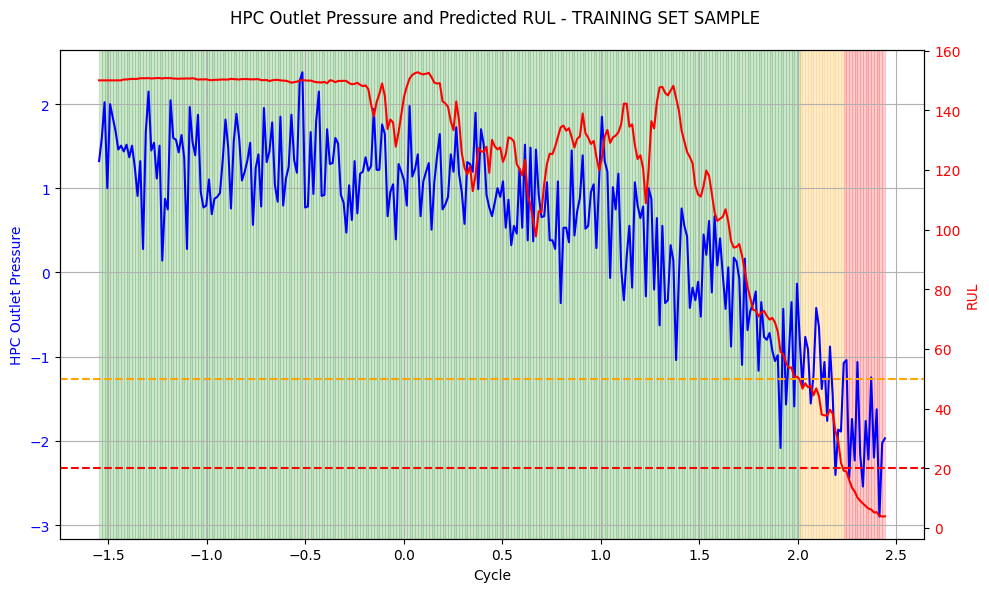

In [17]:
# plot the HPC pressure and the ESTIMATED RUL in the same plot with two y-axes (TEST SAMPLE)

engine_id = df_TEST['engine_id'].unique()[0] # take the first engine in the test set

X_test_sample, y_test_sample = create_windows(df_TEST[df_TEST['engine_id'] == engine_id], window_size=WINDOWS_SIZE)

engine_data = df_TEST[df_TEST['engine_id'] == engine_id]

y_test_sample_pred = model.predict(X_test_sample)
y_test_sample_pred_last = (y_test_sample_pred[:, -1, 0] * train_std['RUL'] ) + train_mean['RUL']
y_test_sample_true_last = (y_test_sample[:, -1] * train_std['RUL'] ) + train_mean['RUL']

cycles = engine_data['cycle'].values
RUL_pred = y_test_sample_pred_last.flatten()  # in case it's shape (n,1)

RUL_pred = [150 for _ in range(0, len(cycles) - len(RUL_pred))] + list(RUL_pred)

print(len(cycles))
print(len(RUL_pred))

def color_from_RUL_pred(lr):
    if lr < 20:
        return 'red'
    elif lr < 50:
        return 'orange'
    else:
        return 'green'

fig, ax1 = plt.subplots(figsize=(10, 6))

# background shading
for i in range(len(cycles) - 1):
    ax1.axvspan(
        cycles[i],
        cycles[i + 1],
        color=color_from_RUL_pred(RUL_pred[i]),
        alpha=0.15
    )

# main signal
ax1.plot(
    cycles,
    engine_data['HPC_outlet_press'],
    color='b',
    label='HPC Outlet Pressure'
)

ax1.set_xlabel('Cycle')
ax1.set_ylabel('HPC Outlet Pressure', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid()

# second axis
ax2 = ax1.twinx()
ax2.plot(cycles, RUL_pred, color='r', label='Predicted RUL')
ax2.set_ylabel('RUL', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# add an horizontal line at RUL=20 and RUL=50 to visualize the thresholds
ax2.axhline(y=20, color='red', linestyle='--', label='RUL=20 Threshold')
ax2.axhline(y=50, color='orange', linestyle='--', label='RUL=50 Threshold')

fig.suptitle(
    f'HPC Outlet Pressure and Predicted RUL - TRAINING SET SAMPLE'
)

fig.tight_layout()
plt.show()